In [ ]:
# Upload du token Kaggle
from google.colab import files
files.upload()  # ← sélectionne ton kaggle.json ici

# Configurer kaggle
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Télécharger le dataset
!kaggle datasets download -d grassknoted/asl-alphabet
!unzip -q asl-alphabet.zip -d asl_data


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/grassknoted/asl-alphabet
License(s): GPL-2.0
asl-alphabet.zip: Skipping, found more recently modified local copy (use --force to force download)
replace asl_data/asl_alphabet_test/asl_alphabet_test/A_test.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [ ]:
!pip uninstall -y mediapipe
!pip install mediapipe==0.10.5


In [ ]:
# Installer les dépendances
#!pip install mediapipe opencv-python gTTS

# Si MediaPipe pose problème avec NumPy :
#!pip uninstall -y mediapipe
#!pip install numpy==1.23.5 --no-binary :all:
#!pip install mediapipe opencv-python-headless

# Import des librairies
import mediapipe as mp
import cv2
import os
import numpy as np
import pandas as pd
from tqdm import tqdm

# Initialisation de MediaPipe (plus robuste ici)
mp_hands = mp.solutions.hands
hands = mp_hands.Hands(
    static_image_mode=False,  # Meilleure détection sur images successives
    max_num_hands=1,          # Peut être augmenté à 2 si nécessaire
    min_detection_confidence=0.7,  # Seuil de détection
    min_tracking_confidence=0.5
)

# Chemin du dataset
dataset_path = 'asl_data/asl_alphabet_train/asl_alphabet_train'

labels = []
keypoints = []

kept_labels = [chr(c) for c in range(ord('A'), ord('Z') + 1)]  # A-Z uniquement

for label in kept_labels:
    folder_path = os.path.join(dataset_path, label)
    for file_name in tqdm(os.listdir(folder_path)[:300]):  # max 300 images/lettre
        file_path = os.path.join(folder_path, file_name)
        try:
            image = cv2.imread(file_path)
            if image is None:
                continue
            image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            results = hands.process(image_rgb)

            if results.multi_hand_landmarks:
                landmarks = results.multi_hand_landmarks[0].landmark

                # Centrage et normalisation autour de la paume (point 0)
                base_x = landmarks[0].x
                base_y = landmarks[0].y

                kp = []
                for lm in landmarks:
                    norm_x = lm.x - base_x
                    norm_y = lm.y - base_y
                    kp.extend([norm_x, norm_y])

                keypoints.append(kp)
                labels.append(label)

        except Exception as e:
            print(f"Erreur avec {file_path} → {str(e)}")
            continue

# Vérification des longueurs
assert len(keypoints) == len(labels)

# Conversion en DataFrame
df = pd.DataFrame(keypoints)
df['label'] = labels

# Sauvegarde CSV
df.to_csv("keypoints_dataset.csv", index=False)
print("✅ Extraction terminée :", df.shape)


100%|██████████| 300/300 [00:11<00:00, 25.69it/s]


✅ Extraction terminée : (4901, 43)


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# Préparation des données
X = df.drop(columns=['label']).values  # keypoints
y = df['label'].values

encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)
y_cat = to_categorical(y_encoded)

X_train, X_test, y_train, y_test = train_test_split(X, y_cat, test_size=0.2, stratify=y_cat, random_state=42)

# ✅ Modèle MLP
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(26, activation='softmax')  # 26 lettres
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Entraînement
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test))


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
123/123 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.1226 - loss: 3.0647 - val_accuracy: 0.4006 - val_loss: 2.2421
Epoch 2/20
123/123 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3102 - loss: 2.2162 - val_accuracy: 0.6279 - val_loss: 1.4629
Epoch 3/20
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4698 - loss: 1.6043 - val_accuracy: 0.7492 - val_loss: 1.0555
Epoch 4/20
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5981 - loss: 1.2465 - val_accuracy: 0.7880 - val_loss: 0.8632
Epoch 5/20
123/123 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6787 - loss: 1.0458 - val_accuracy: 0.8084 - val_loss: 0.7428
Epoch 6/20
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6959 - loss: 0.9082 - val_accuracy: 0.8257 - val_loss: 0.6732
Epoch 7/20
123/123 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7426 - loss: 0.8386 - val_accuracy: 0.8552 - val_loss: 0.6160
Epoch 8/20
123/123 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7533 - loss: 0.8027 - val_accuracy: 0.

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
              precision    recall  f1-score   support

           A       0.93      0.82      0.87        33
           B       0.97      0.97      0.97        39
           C       0.97      0.97      0.97        34
           D       0.95      0.93      0.94        42
           E       0.82      0.95      0.88        38
           F       0.96      0.91      0.93        47
           G       0.97      0.92      0.94        37
           H       0.98      1.00      0.99        43
           I       0.86      0.88      0.87        42
           J       0.95      0.93      0.94        42
           K       0.95      0.88      0.91        41
           L       0.98      0.94      0.96        48
           M       0.67      0.42      0.52        19
           N       0.67      0.95      0.78        19
           O       0.88      0.93      0.90        40
           P       0.91      0.83      0.87        35
           Q       0.83      0.91      0.8

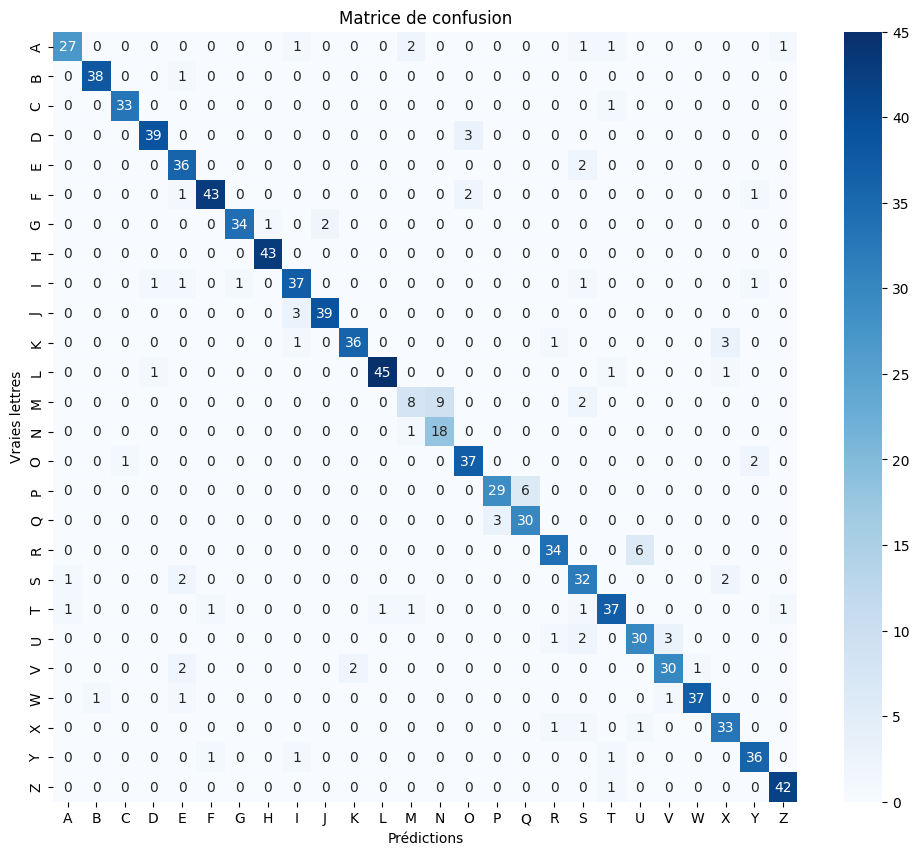

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Prédictions
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

# Rapport
print(classification_report(y_true, y_pred_classes, target_names=encoder.classes_))

# Matrice de confusion
plt.figure(figsize=(12, 10))
cm = confusion_matrix(y_true, y_pred_classes)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=encoder.classes_, yticklabels=encoder.classes_)
plt.title("Matrice de confusion")
plt.ylabel("Vraies lettres")
plt.xlabel("Prédictions")
plt.show()


In [ ]:
from google.colab import files

# Upload d'une image test
uploaded = files.upload()
test_image_path = list(uploaded.keys())[0]

print("📷 Image chargée :", test_image_path)


Saving f.jpg to f.jpg
📷 Image chargée : f.jpg


In [ ]:
# Extraction keypoints image unique
def extract_keypoints_from_image(image_path):
    image = cv2.imread(image_path)
    if image is None:
        print("❌ Erreur : image non chargée.")
        return None
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    results = hands.process(image_rgb)
    if results.multi_hand_landmarks:
        kp = [coord for lm in results.multi_hand_landmarks[0].landmark for coord in (lm.x, lm.y)]
        return np.array(kp).reshape(1, -1)
    else:
        print("❌ Aucune main détectée.")
        return None


In [ ]:
from gtts import gTTS
from IPython.display import Audio, display

def parler_lettre(lettre):
    tts = gTTS(f"La lettre détectée est {lettre}", lang='fr')
    tts.save("lettre.mp3")
    return Audio("lettre.mp3", autoplay=True)


In [ ]:
keypoints = extract_keypoints_from_image(test_image_path)
if keypoints is not None:
    prediction = model.predict(keypoints)
    predicted_index = np.argmax(prediction)
    predicted_letter = encoder.inverse_transform([predicted_index])[0]
    print(f"✅ Lettre prédite : {predicted_letter}")
    audio = parler_lettre(predicted_letter)
    display(audio)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
✅ Lettre prédite : C


In [ ]:
# Upload d'une vidéo test (format .mp4 recommandé)
uploaded = files.upload()
video_path = list(uploaded.keys())[0]


NameError: name 'files' is not defined

In [ ]:
def predict_from_video(video_path, skip_frames=5):
    import cv2
    import numpy as np
    import mediapipe as mp

    # Initialisation MediaPipe Hands
    mp_hands = mp.solutions.hands
    hands = mp_hands.Hands(static_image_mode=True, max_num_hands=1)

    # Nombre attendu de coordonnées : 21 points * (x, y)
    EXPECTED_KP_SIZE = 42

    # Ouverture vidéo
    cap = cv2.VideoCapture(video_path)
    frame_idx = 0
    detected_letters = []

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        if frame_idx % skip_frames == 0:
            image_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            results = hands.process(image_rgb)

            if results.multi_hand_landmarks:
                kp = [coord for lm in results.multi_hand_landmarks[0].landmark for coord in (lm.x, lm.y)]
                if len(kp) == EXPECTED_KP_SIZE:
                    prediction = model.predict(np.array(kp).reshape(1, -1))
                    predicted_index = np.argmax(prediction)
                    predicted_letter = encoder.inverse_transform([predicted_index])[0]
                    detected_letters.append(predicted_letter)
                    print(f"[Frame {frame_idx}] Lettre détectée : {predicted_letter}")

        frame_idx += 1

    cap.release()
    return detected_letters


In [ ]:
def remove_repeats(seq):
    result = []
    for ch in seq:
        if not result or result[-1] != ch:
            result.append(ch)
    return result


In [ ]:
from gtts import gTTS
from IPython.display import Audio, display

def parler_lettre(texte):
    tts = gTTS(f"Le mot détecté est {texte}", lang='fr')
    tts.save("mot_detecte.mp3")
    return Audio("mot_detecte.mp3", autoplay=True)


In [ ]:
letters = predict_from_video(video_path, skip_frames=5)

if letters:
    print("\n🧾 Lettres détectées dans la vidéo :")
    print(" →", ' '.join(letters))

    word = ''.join(remove_repeats(letters))
    print("\n📌 Mot estimé :", word)

    audio = parler_lettre(word)
    display(audio)
else:
    print("❌ Aucune lettre détectée dans la vidéo.")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
[Frame 0] Lettre détectée : N
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
[Frame 5] Lettre détectée : N
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
[Frame 10] Lettre détectée : N
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
[Frame 15] Lettre détectée : N
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
[Frame 20] Lettre détectée : N
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
[Frame 25] Lettre détectée : N
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
[Frame 30] Lettre détectée : N
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
[Frame 35] Lettre détectée : N
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step
[Frame 40] Lettre détectée : N
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
[Frame 45] Lettre détectée : Q
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
[Frame 70] Lettre détectée : Q
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
[Frame 75] Lettre détectée : P
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
[Frame 80] Lettre détectée : P
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
[Frame 85] Lettre détectée : P
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/

##############################################################CNN#############################


In [ ]:
!pip install tensorflow matplotlib seaborn tqdm scikit-learn


In [ ]:
# ✅ Étape 1 : Imports
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import img_to_array, load_img
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, confusion_matrix


In [ ]:
# ✅ Étape 2 : Chargement des images (depuis asl_data)
image_size = (64, 64)
dataset_path = 'asl_data/asl_alphabet_train/asl_alphabet_train'
kept_labels = [chr(c) for c in range(ord('A'), ord('Z') + 1)]
limit_per_class = 500  # tu peux augmenter si tu veux plus de données

images = []
labels = []

for label in kept_labels:
    folder_path = os.path.join(dataset_path, label)
    files = os.listdir(folder_path)[:limit_per_class]
    for file in tqdm(files, desc=f"Chargement {label}"):
        try:
            img_path = os.path.join(folder_path, file)
            img = load_img(img_path, target_size=image_size)
            img_array = img_to_array(img) / 255.0  # normalisation
            images.append(img_array)
            labels.append(label)
        except:
            continue

X = np.array(images)
y = np.array(labels)
print("✅ Dataset image shape :", X.shape)


Chargement Z: 100%|██████████| 500/500 [00:00<00:00, 1074.46it/s]


✅ Dataset image shape : (13000, 64, 64, 3)


In [ ]:
# ✅ Étape 3 : Encodage des labels + split
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)
y_cat = to_categorical(y_encoded)

X_train, X_test, y_train, y_test = train_test_split(X, y_cat, test_size=0.2, stratify=y_cat, random_state=42)


In [ ]:
# ✅ Étape 4 : Définition du modèle CNN
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(64, 64, 3)),
    MaxPooling2D(2, 2),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(len(kept_labels), activation='softmax')  # 26 classes A-Z
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │     1,605,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 26)             │         3,354 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,628,506 (6.21 MB)

 Trainable params: 1,628,506 (6.21 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ✅ Étape 5 : Entraînement
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    epochs=15,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop]
)


Epoch 1/15
325/325 ━━━━━━━━━━━━━━━━━━━━ 66s 194ms/step - accuracy: 0.1195 - loss: 3.0073 - val_accuracy: 0.5496 - val_loss: 1.5465
Epoch 2/15
325/325 ━━━━━━━━━━━━━━━━━━━━ 61s 187ms/step - accuracy: 0.5049 - loss: 1.5420 - val_accuracy: 0.7338 - val_loss: 0.8852
Epoch 3/15
325/325 ━━━━━━━━━━━━━━━━━━━━ 83s 189ms/step - accuracy: 0.6864 - loss: 0.9562 - val_accuracy: 0.8296 - val_loss: 0.5661
Epoch 4/15
325/325 ━━━━━━━━━━━━━━━━━━━━ 80s 183ms/step - accuracy: 0.7805 - loss: 0.6556 - val_accuracy: 0.8658 - val_loss: 0.4261
Epoch 5/15
325/325 ━━━━━━━━━━━━━━━━━━━━ 83s 185ms/step - accuracy: 0.8332 - loss: 0.5043 - val_accuracy: 0.8692 - val_loss: 0.4256
Epoch 6/15
325/325 ━━━━━━━━━━━━━━━━━━━━ 81s 182ms/step - accuracy: 0.8552 - loss: 0.4120 - val_accuracy: 0.9085 - val_loss: 0.3068
Epoch 7/15
325/325 ━━━━━━━━━━━━━━━━━━━━ 83s 186ms/step - accuracy: 0.8790 - loss: 0.3510 - val_accuracy: 0.9177 - val_loss: 0.2751
Epoch 8/15
325/325 ━━━━━━━━━━━━━━━━━━━━ 59s 181ms/step - accuracy: 0.9140 - loss: 0

82/82 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step
              precision    recall  f1-score   support

           A       0.92      0.97      0.95       100
           B       0.91      0.91      0.91       100
           C       0.99      0.98      0.98       100
           D       0.98      0.95      0.96       100
           E       0.95      0.88      0.91       100
           F       0.97      1.00      0.99       100
           G       0.97      0.88      0.92       100
           H       0.88      0.99      0.93       100
           I       0.97      0.93      0.95       100
           J       0.96      0.98      0.97       100
           K       0.96      0.92      0.94       100
           L       0.94      0.98      0.96       100
           M       0.97      0.87      0.92       100
           N       0.86      0.97      0.91       100
           O       0.97      0.93      0.95       100
           P       1.00      0.98      0.99       100
           Q       0.99      1.00      1.

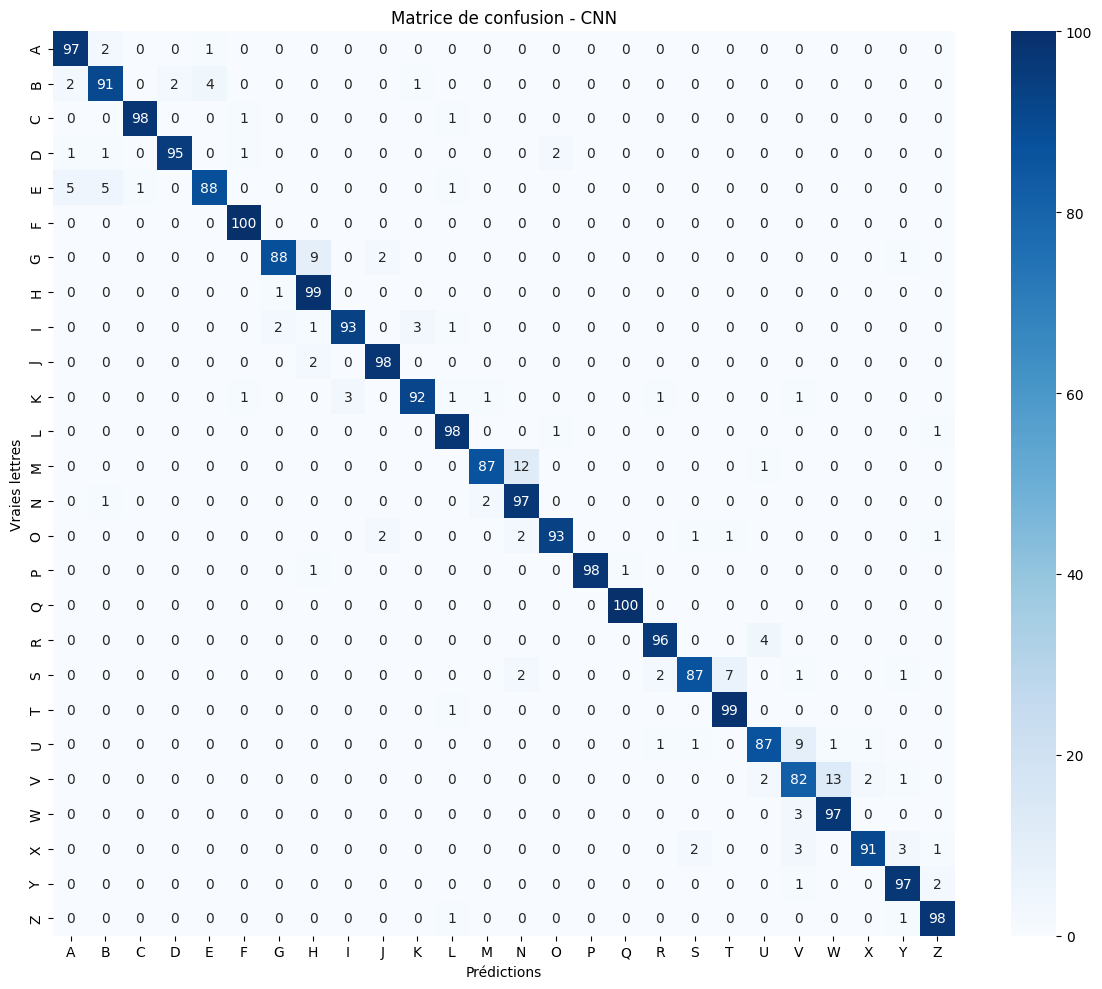

In [ ]:
# ✅ Étape 6 : Évaluation
y_pred_probs = model.predict(X_test)
y_pred_classes = np.argmax(y_pred_probs, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

# Rapport texte
print(classification_report(y_true_classes, y_pred_classes, target_names=encoder.classes_))

# Matrice de confusion
cm = confusion_matrix(y_true_classes, y_pred_classes)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=encoder.classes_, yticklabels=encoder.classes_)
plt.title("Matrice de confusion - CNN")
plt.ylabel("Vraies lettres")
plt.xlabel("Prédictions")
plt.tight_layout()
plt.show()


In [ ]:
from google.colab import files
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import numpy as np

# 📤 Upload image
uploaded = files.upload()
test_image_path = list(uploaded.keys())[0]

# 🔮 Prédiction sur l'image
def predict_cnn_image(image_path):
    img = load_img(image_path, target_size=(64, 64))
    img_array = img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)  # reshape (1, 64, 64, 3)

    prediction = model.predict(img_array)
    predicted_index = np.argmax(prediction)
    predicted_letter = encoder.inverse_transform([predicted_index])[0]

    print(f"✅ Lettre prédite par CNN : {predicted_letter}")
    return predicted_letter

# 🔁 Test
letter = predict_cnn_image(test_image_path)


Saving T_test.jpg to T_test.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
✅ Lettre prédite par CNN : T


In [ ]:
from google.colab import files
import cv2
from collections import deque, Counter

# 📤 Upload vidéo
uploaded = files.upload()
video_path = list(uploaded.keys())[0]

# 🧠 Prédiction frame par frame avec stabilisation (vote)
def predict_cnn_video(video_path, frame_skip=5, vote_window=7):
    cap = cv2.VideoCapture(video_path)
    frame_idx = 0
    detected_letters = []
    history = deque(maxlen=vote_window)

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        if frame_idx % frame_skip == 0:
            try:
                frame_resized = cv2.resize(frame, (64, 64))
                img_array = frame_resized / 255.0
                img_array = np.expand_dims(img_array, axis=0)

                prediction = model.predict(img_array)
                predicted_index = np.argmax(prediction)
                predicted_letter = encoder.inverse_transform([predicted_index])[0]
                history.append(predicted_letter)

                if len(history) == vote_window:
                    vote = Counter(history).most_common(1)[0][0]
                    if not detected_letters or detected_letters[-1] != vote:
                        detected_letters.append(vote)
                        print(f"[Frame {frame_idx}] ✅ Lettre stabilisée : {vote}")

            except Exception as e:
                print(f"[Frame {frame_idx}] ⚠️ Erreur : {e}")

        frame_idx += 1

    cap.release()
    return detected_letters

# 🧪 Exécution
letters = predict_cnn_video(video_path)

if letters:
    print("\n🧾 Lettres détectées dans la vidéo :")
    print(" →", ' '.join(letters))
    word = ''.join(letters)
    print("\n📌 Mot estimé :", word)
else:
    print("❌ Aucune lettre détectée dans la vidéo.")


Saving video2.mp4 to video2.mp4
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
[Frame 30] ✅ Lettre stabilisée : F
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
[Frame 110] ✅ Lettre stabilisée : D
1/1 ━━━━━━━━━━━━━━━━━━━